In [1]:
import pandas as pd

df = pd.read_csv("../datasets/urls.csv")
print(df.head())

   Querylength  domain_token_count  path_token_count  avgdomaintokenlen  \
0            0                   2                12                5.5   
1            0                   3                12                5.0   
2            2                   2                11                4.0   
3            0                   2                 7                4.5   
4           19                   2                10                6.0   

   longdomaintokenlen  avgpathtokenlen  tld  charcompvowels  charcompace  \
0                   8         4.083334    2              15            7   
1                  10         3.583333    3              12            8   
2                   5         4.750000    2              16           11   
3                   7         5.714286    2              15           10   
4                   9         2.250000    2               9            5   

   ldl_url  ...  SymbolCount_FileName  SymbolCount_Extension  \
0        0  ...             

In [2]:
print(df.columns)

Index(['Querylength', 'domain_token_count', 'path_token_count',
       'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld',
       'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path',
       'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path',
       'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength',
       'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio',
       'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio',
       'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL',
       'ISIpAddressInDomainName', 'CharacterContinuityRate',
       'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount',
       'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount',
       'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count',
       'Directory_LetterCount', 'Filename_LetterCount',
       'Extension_LetterCount', 'Query_LetterCount', 'LongestPathToken

In [3]:
print(df["URL_Type_obf_Type"].value_counts())

URL_Type_obf_Type
benign      7781
phishing    7586
Name: count, dtype: int64


In [4]:
X = df.drop("URL_Type_obf_Type", axis=1)
y = df["URL_Type_obf_Type"]

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
print(le.classes_)

['benign' 'phishing']


In [7]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9843851659076123

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2338
           1       0.99      0.98      0.98      2273

    accuracy                           0.98      4611
   macro avg       0.98      0.98      0.98      4611
weighted avg       0.98      0.98      0.98      4611


Confusion Matrix:
[[2311   27]
 [  45 2228]]


In [11]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

                    feature  importance
29           domainUrlRatio    0.071113
20             domainlength    0.069483
1        domain_token_count    0.065021
68       SymbolCount_Domain    0.063831
6                       tld    0.057391
..                      ...         ...
17             dld_filename    0.000137
33             isPortEighty    0.000000
32               executable    0.000000
35  ISIpAddressInDomainName    0.000000
15               dld_domain    0.000000

[79 rows x 2 columns]


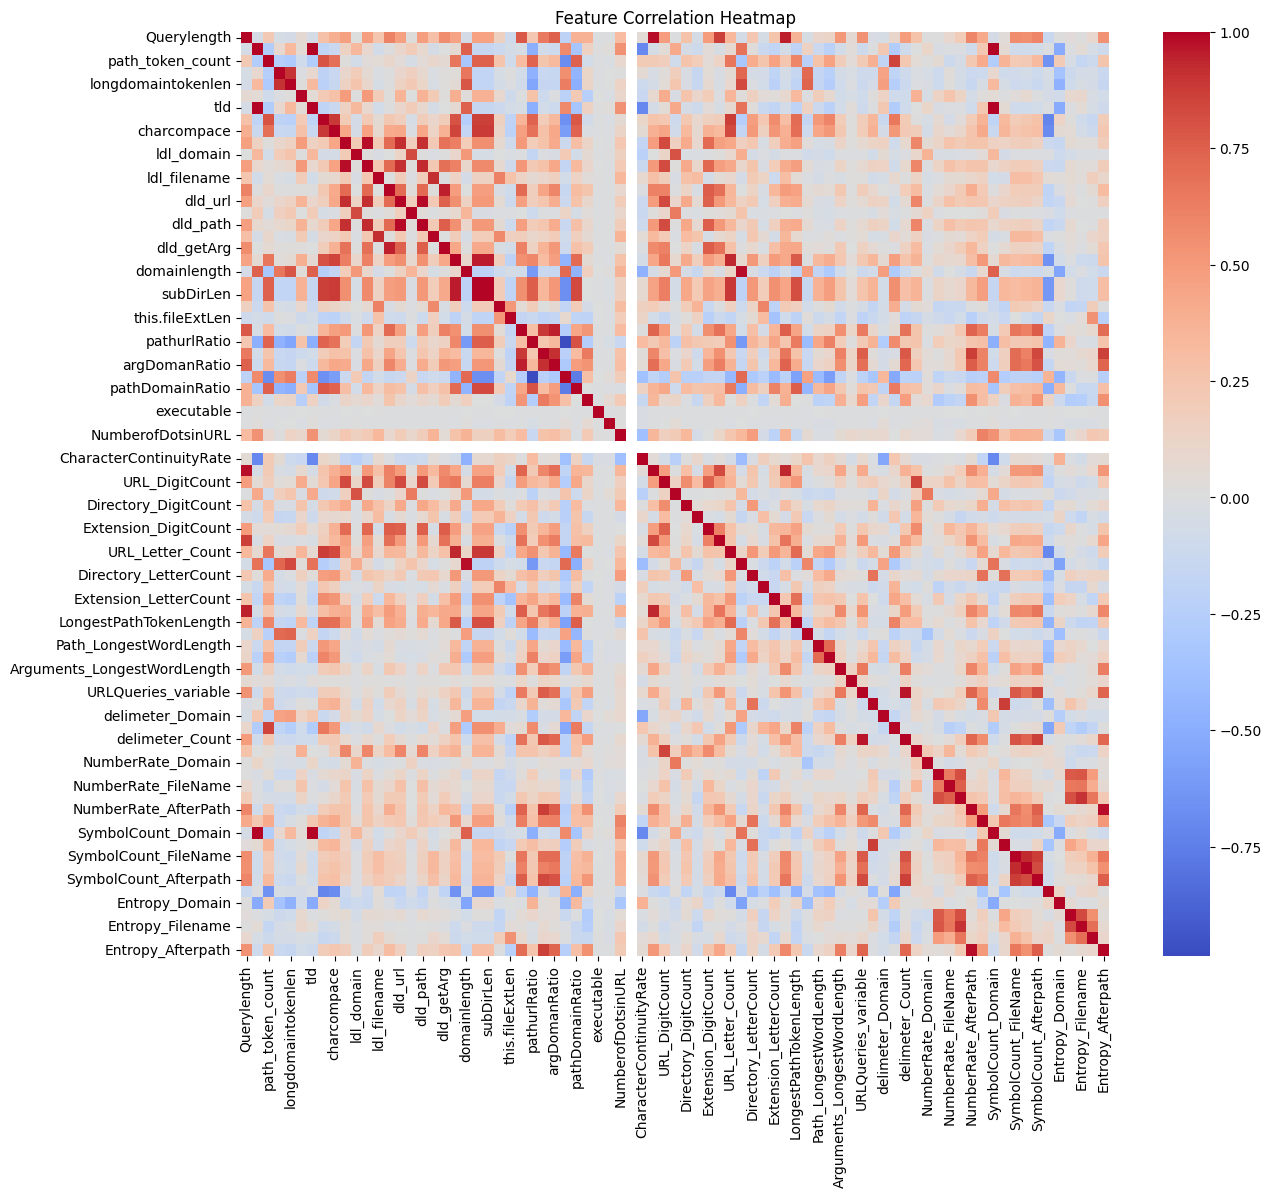

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X.corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=False,        
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [13]:
corr_matrix = X.corr()

strong_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        
        corr_value = corr_matrix.iloc[i, j]

        strong_corr.append((
            corr_matrix.columns[i],
            corr_matrix.columns[j],
            corr_value
        ))

strong_corr = sorted(
    strong_corr,
    key=lambda x: x[2],
    reverse=True
)

for feature1, feature2, corr in strong_corr[:15]:
    print(feature1, "<->", feature2, ":", round(corr, 2))

tld <-> domain_token_count : 1.0
subDirLen <-> pathLength : 1.0
dld_path <-> dld_url : 0.99
ldl_path <-> ldl_url : 0.98
pathLength <-> urlLen : 0.96
subDirLen <-> urlLen : 0.96
argDomanRatio <-> ArgLen : 0.95
dld_getArg <-> ldl_getArg : 0.95
dld_path <-> ldl_path : 0.93
dld_url <-> ldl_url : 0.92
dld_filename <-> ldl_filename : 0.92
dld_url <-> ldl_path : 0.92
dld_path <-> ldl_url : 0.91
argDomanRatio <-> ArgUrlRatio : 0.91
longdomaintokenlen <-> avgdomaintokenlen : 0.91


In [14]:
unique_features = set()

for f1, f2, corr in strong_corr[:15]:
    unique_features.add(f1)
    unique_features.add(f2)

print(sorted(unique_features))
print(len(unique_features))

['ArgLen', 'ArgUrlRatio', 'argDomanRatio', 'avgdomaintokenlen', 'dld_filename', 'dld_getArg', 'dld_path', 'dld_url', 'domain_token_count', 'ldl_filename', 'ldl_getArg', 'ldl_path', 'ldl_url', 'longdomaintokenlen', 'pathLength', 'subDirLen', 'tld', 'urlLen']
18


In [15]:
selected_features = list(unique_features)

print(selected_features)

['longdomaintokenlen', 'subDirLen', 'avgdomaintokenlen', 'dld_getArg', 'dld_url', 'ldl_filename', 'argDomanRatio', 'urlLen', 'ArgLen', 'domain_token_count', 'tld', 'ldl_path', 'pathLength', 'dld_filename', 'ArgUrlRatio', 'ldl_getArg', 'dld_path', 'ldl_url']


In [16]:
X = df[selected_features]
X.head()

,longdomaintokenlen,subDirLen,avgdomaintokenlen,dld_getArg,dld_url,ldl_filename,argDomanRatio,urlLen,ArgLen,domain_token_count,tld,ldl_path,pathLength,dld_filename,ArgUrlRatio,ldl_getArg,dld_path,ldl_url
0,8,61,5.5,0,0,0,0.166667,80,2,2,2,0,61,0,0.025000,0,0,0
1,10,54,5.0,0,0,2,0.117647,78,2,3,3,2,54,0,0.025641,0,0,2
2,5,54,4.0,0,0,0,0.777778,71,7,2,2,0,54,0,0.098592,0,0,0
3,7,47,4.5,0,0,0,0.200000,64,2,2,2,0,47,0,0.031250,0,0,0
4,9,48,6.0,0,0,0,2.692308,68,35,2,2,0,48,0,0.514706,0,0,0


In [17]:
y = df["URL_Type_obf_Type"]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)


['benign' 'phishing']


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1557
           1       0.98      0.95      0.96      1517

    accuracy                           0.97      3074
   macro avg       0.97      0.97      0.97      3074
weighted avg       0.97      0.97      0.97      3074



In [21]:
import joblib

# joblib.dump(model, "./temp/model.pkl")
# joblib.dump(selected_features, "./temp/feature_names.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']